Image 1 vessel coverage: 71.41%


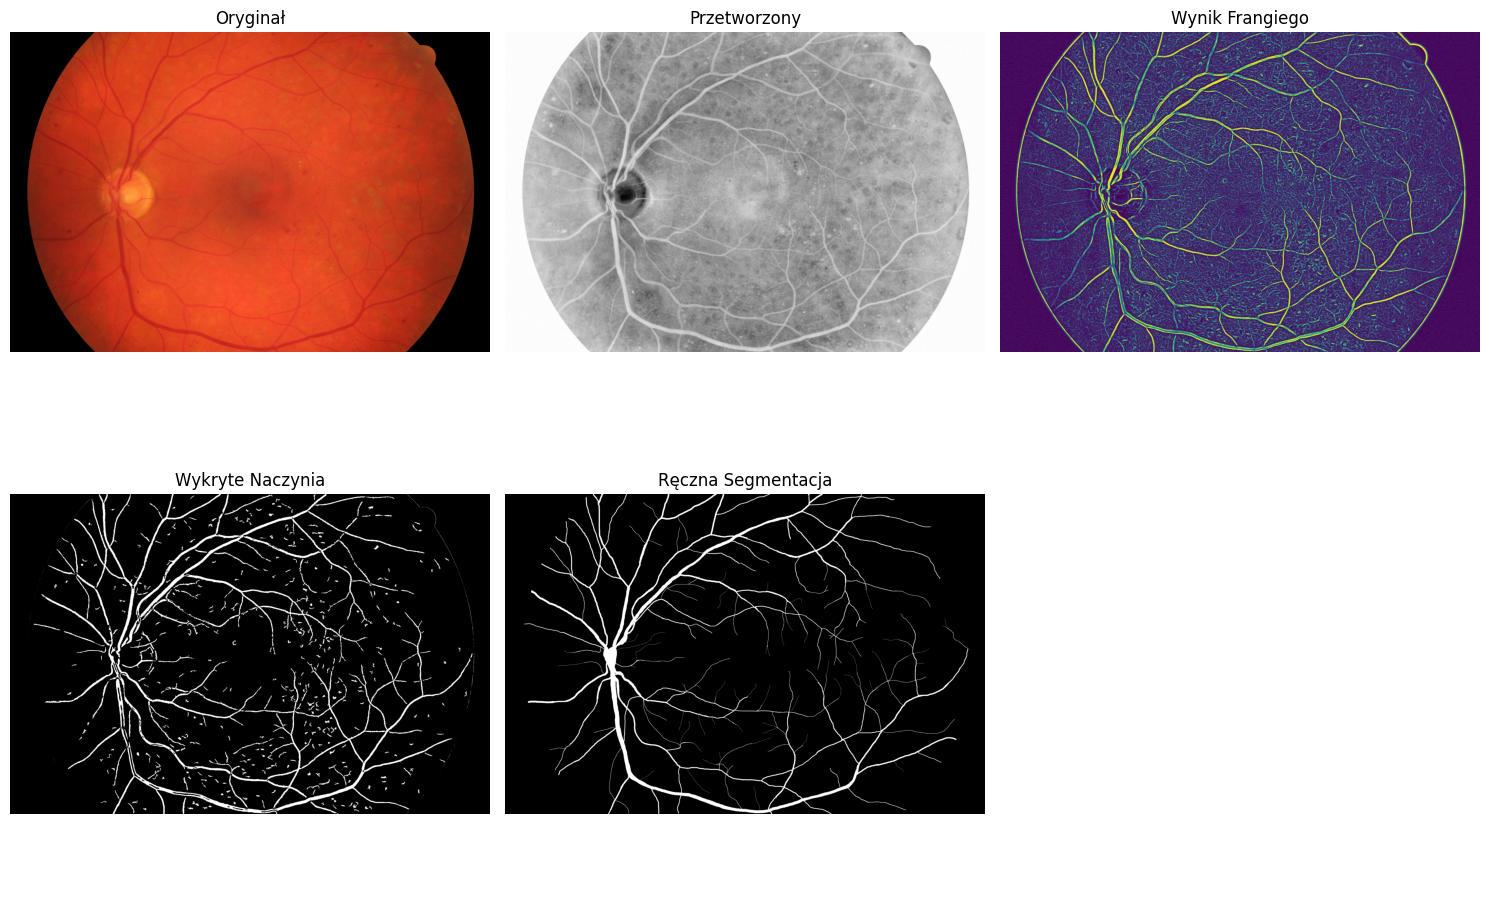

Image 1 vessel coverage: 71.41%


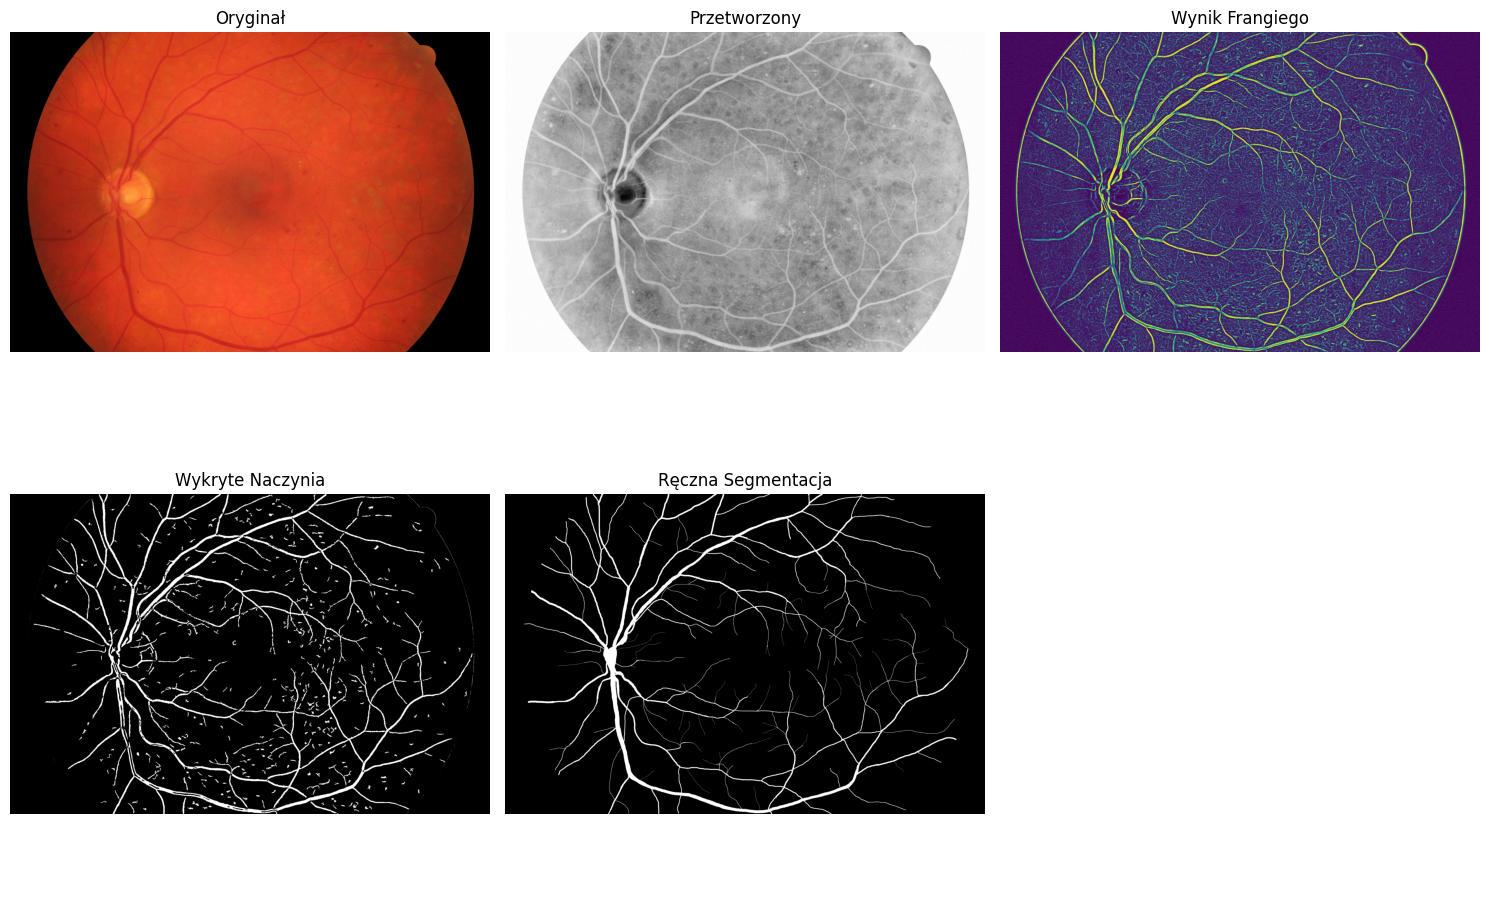

=== TWORZENIE DANYCH TRENINGOWYCH ===
Przetwarzanie obrazu 1...
Utworzono 50000 próbek treningowych
Rozkład klas przed balansowaniem: {np.int64(0): np.int64(46781), np.int64(1): np.int64(3219)}
Rozkład klas po balansowaniu: {np.int64(0): np.int64(10000), np.int64(1): np.int64(3219)}
Trenowanie klasyfikatora...
Dokładność na zbiorze testowym: 0.8094

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      2000
           1       0.71      0.36      0.48       644

    accuracy                           0.81      2644
   macro avg       0.77      0.66      0.68      2644
weighted avg       0.80      0.81      0.79      2644


=== TESTOWANIE KLASYFIKATORA ===
[predict_vessels_with_classifier] Start: patch_size=5, step=10
[predict_vessels_with_classifier] Przetworzono 5000 patchy...
[predict_vessels_with_classifier] Przetworzono 10000 patchy...
[predict_vessels_with_classifier] Przetworzono 15000 patchy...
[predict_vessel

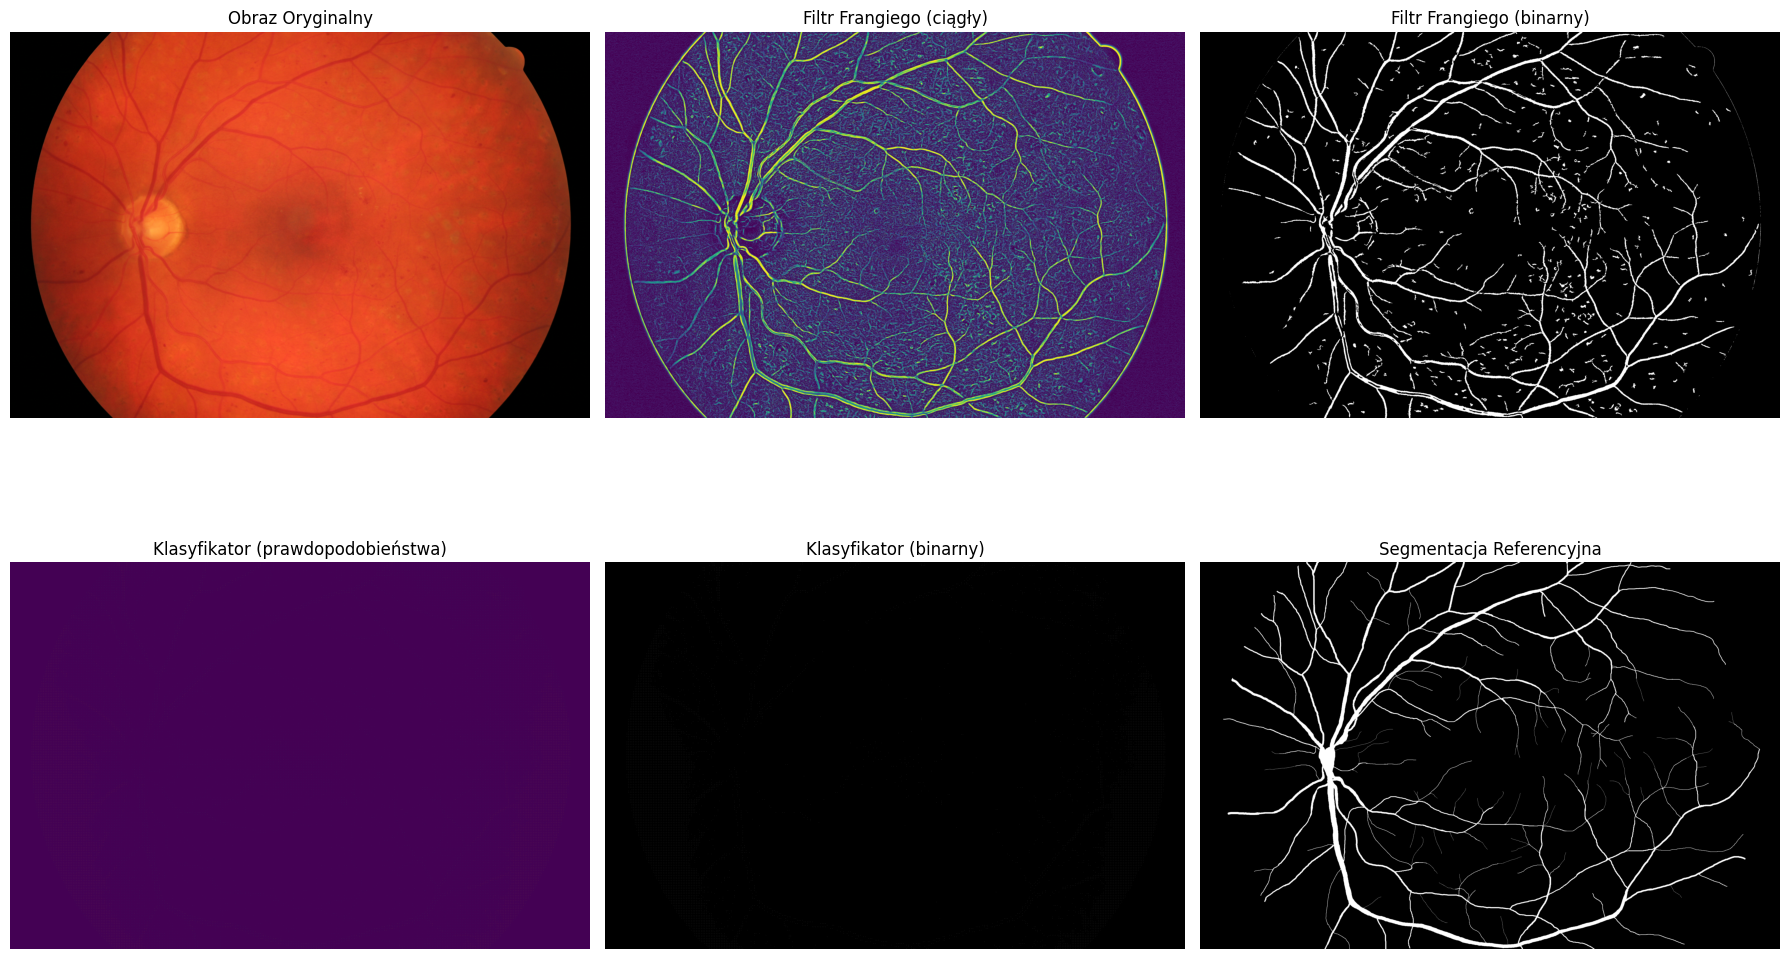

=== OCENA METOD ===
Filtr Frangiego:
  IoU: 0.4314
  Sensitivity: 0.7147

Klasyfikator RF:
  IoU: 0.0027
  Sensitivity: 0.0027

=== SELEKCJA CECH ===
Wybrano 6 najważniejszych cech (z 12)
Log: zakończono selekcję cech
=== TUNING I TRENING ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Najlepsze parametry: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Najlepszy wynik cross-val: 0.8067
Log: zakończono tuning i trening
=== SZYBKA PREDYKCJA NA OBRAZIE TESTOWYM ===


Wpisywanie wyników: 100%|██████████| 6903872/6903872 [00:02<00:00, 2687546.79it/s]


Log: zakończono predykcję


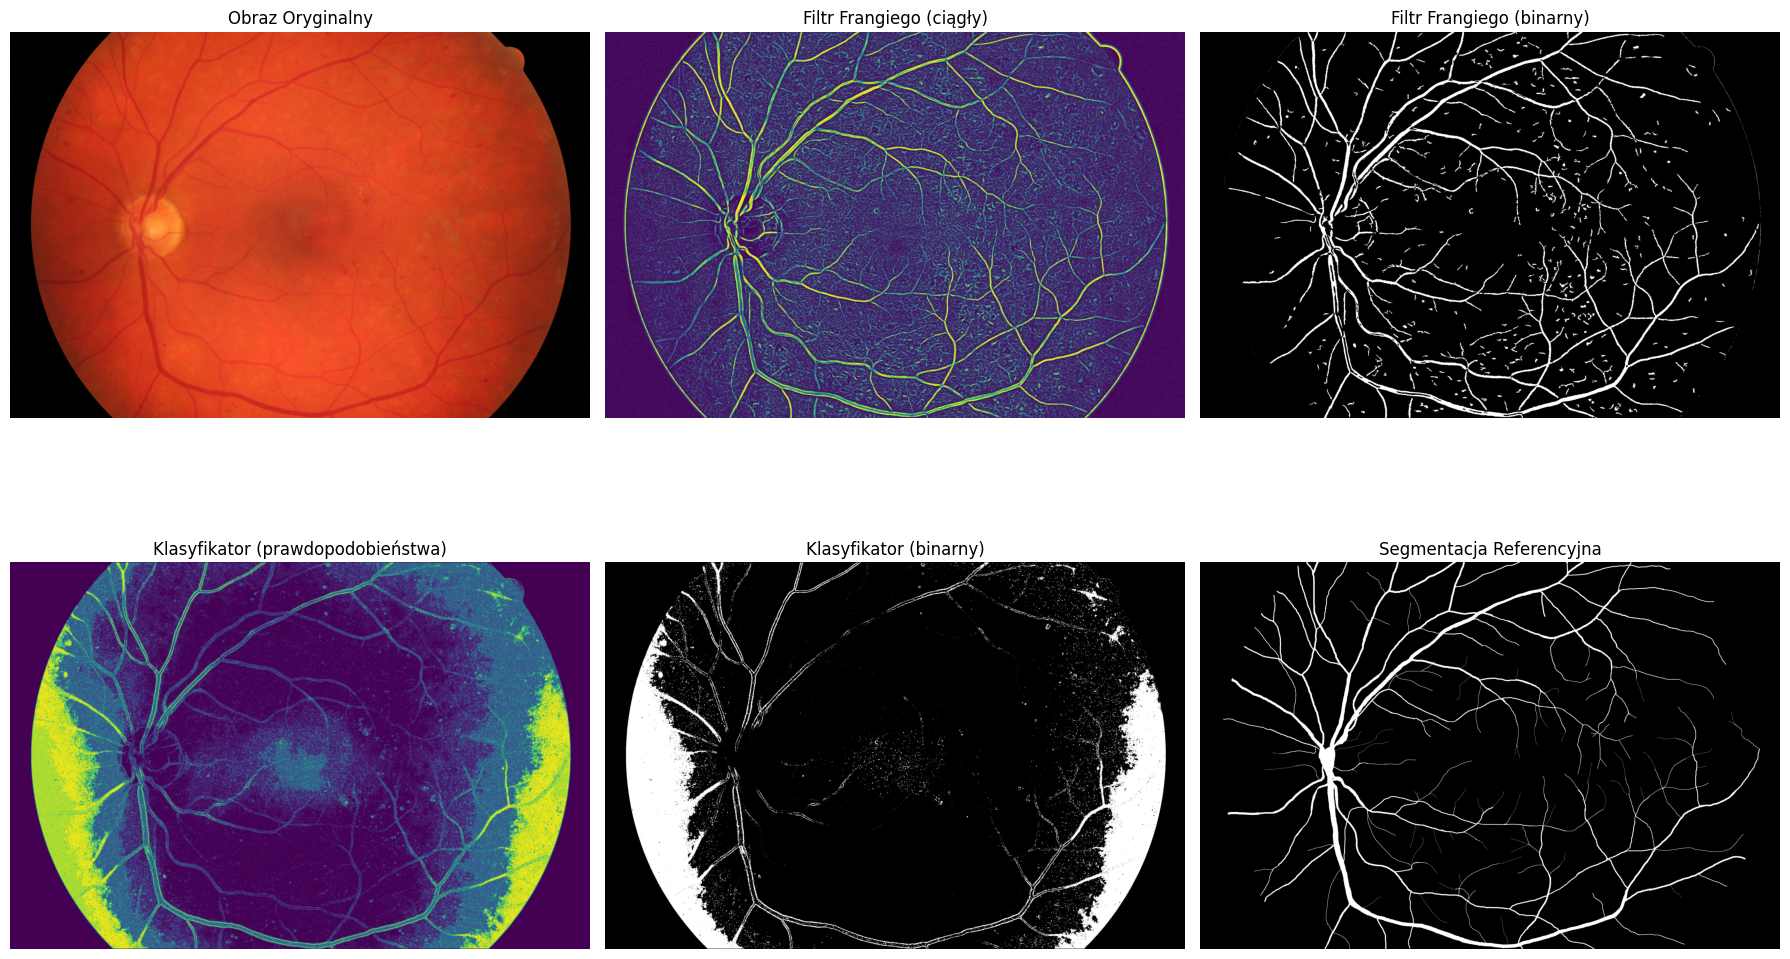

Filtr Frangiego:
  IoU: 0.4314
  Sensitivity: 0.7147

Klasyfikator RF (fast):
  IoU: 0.0789
  Sensitivity: 0.2628



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float, exposure, feature
from skimage.filters import frangi, unsharp_mask, threshold_otsu
from scipy.ndimage import gaussian_filter
from skimage.morphology import remove_small_objects, binary_closing, disk, remove_small_holes
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ====== Ładowanie Obrazów ======
dnoOka = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/images/0{i}_dr.jpg"
        filename2 = f"all/images/0{i}_g.jpg"
        filename3 = f"all/images/0{i}_h.jpg"
    else:
        filename1 = f"all/images/{i}_dr.jpg"
        filename2 = f"all/images/{i}_g.jpg"
        filename3 = f"all/images/{i}_h.jpg"
        
    img1 = cv2.imread(filename1)
    img2 = cv2.imread(filename2)
    img3 = cv2.imread(filename3)
    dnoOka.append(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))


naczynia = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/manual1/0{i}_dr.tif"
        filename2 = f"all/manual1/0{i}_g.tif"
        filename3 = f"all/manual1/0{i}_h.tif"
    else:
        filename1 = f"all/manual1/{i}_dr.tif"
        filename2 = f"all/manual1/{i}_g.tif"
        filename3 = f"all/manual1/{i}_h.tif"
    naczynia.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))

maski = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/mask/0{i}_dr_mask.tif"
        filename2 = f"all/mask/0{i}_g_mask.tif"
        filename3 = f"all/mask/0{i}_h_mask.tif"
    else:
        filename1 = f"all/mask/{i}_dr_mask.tif"
        filename2 = f"all/mask/{i}_g_mask.tif"
        filename3 = f"all/mask/{i}_h_mask.tif"
    maski.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))

dnoOka = dnoOka[:1]
naczynia = naczynia[:1]
maski = maski[:1]

# ====== Wstępne Przetwarzanie ======
def preprocess(img):
    # Konwersja do skali szarości
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Odwrócenie obrazu (naczynia stają się jasne)
    inverted = 255 - gray
    
    #  dla poprawy kontrastu
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(16, 16))
    enhanced = clahe.apply(inverted)
    
    # Korekcja gamma
    gamma_corrected = exposure.adjust_gamma(enhanced, gamma=0.7)
    
    return img_as_float(gamma_corrected)

# Przetwarzanie wszystkich obrazów z listy dnoOka
processed = [preprocess(img) for img in dnoOka]

# ====== Filtr Frangiego ======
def detect_vessels(img):
    # Wykrywanie cienkich naczyń (mniejsze sigmy)
    thin_vessels = frangi(
        img,
        sigmas=range(1, 4),  # Małe skale dla cienkich naczyń
        beta=0.5,
        gamma=0.01,
        black_ridges=False
    )
    
    # Wykrywanie grubych naczyń (większe sigmy)
    thick_vessels = frangi(
        img,
        sigmas=range(4, 10),  # Większe skale dla grubych naczyń
        beta=0.5,
        gamma=0.001,
        black_ridges=False
    )

    # Łączenie wyników
    combined = np.maximum(thin_vessels, thick_vessels)
    # Normalizacja wyników do zakresu [0, 1]
    return (combined - combined.min()) / (combined.max() - combined.min())

# Wykrywanie naczyń dla wszystkich przetworzonych obrazów
vessels = [detect_vessels(img) for img in processed]

# ====== PostProcessing ======
binaries = []
for i, v in enumerate(vessels):
    # Dynamiczne progowanie (metoda Otsu)
    thresh = threshold_otsu(v)
    # Zastosowanie progu
    binary = v > thresh * 1.3 # Nieco wyższy próg, aby zmniejszyć fałszywe pozytywy
    
    # czyszczenie
    
    cleaned = binary_closing(binary, footprint=disk(1)) # Zamknięcie binarne do wypełniania małych przerw
    cleaned = remove_small_objects(cleaned, min_size=150) # Usunięcie małych, nieistotnych obiektów
    cleaned = remove_small_holes(cleaned, area_threshold=50) # Usunięcie małych dziur w naczyniach
    cleaned = cleaned * maski[i]  # mask_region to binarna maska (1 wewnątrz, 0 na zewnątrz)


    overlap = np.logical_and(cleaned, naczynia[i] > 0)
    coverage = np.sum(overlap) / np.sum(naczynia[i] > 0)
    print(f"Image {i+1} vessel coverage: {coverage:.2%}")

    binaries.append(cleaned)

# ====== Wizualizacja ======
def compare_results(original, processed, frangi, binary, manual):
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))

    ax[0,0].imshow(original, cmap='gray')
    ax[0,0].set_title("Oryginał")
    
    ax[0,1].imshow(processed, cmap='gray')
    ax[0,1].set_title("Przetworzony")
    
    ax[0,2].imshow(frangi, cmap='viridis')
    ax[0,2].set_title("Wynik Frangiego")
    
    ax[1,0].imshow(binary, cmap='gray')
    ax[1,0].set_title("Wykryte Naczynia")
    
    ax[1,1].imshow(manual, cmap='gray')
    ax[1,1].set_title("Ręczna Segmentacja")
    
    for a in ax.flat:
        a.axis('off')
    
    plt.tight_layout()
    plt.show()

# Porównanie wyników dla pierwszego obrazu
compare_results(
    dnoOka[0], 
    processed[0], 
    vessels[0], 
    binaries[0], 
    naczynia[0]
)
# ====== Ładowanie Obrazów ======
dnoOka = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/images/0{i}_dr.jpg"
        filename2 = f"all/images/0{i}_g.jpg"
        filename3 = f"all/images/0{i}_h.jpg"
    else:
        filename1 = f"all/images/{i}_dr.jpg"
        filename2 = f"all/images/{i}_g.jpg"
        filename3 = f"all/images/{i}_h.jpg"
        
    img1 = cv2.imread(filename1)
    img2 = cv2.imread(filename2)
    img3 = cv2.imread(filename3)
    dnoOka.append(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))


naczynia = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/manual1/0{i}_dr.tif"
        filename2 = f"all/manual1/0{i}_g.tif"
        filename3 = f"all/manual1/0{i}_h.tif"
    else:
        filename1 = f"all/manual1/{i}_dr.tif"
        filename2 = f"all/manual1/{i}_g.tif"
        filename3 = f"all/manual1/{i}_h.tif"
    naczynia.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))

maski = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/mask/0{i}_dr_mask.tif"
        filename2 = f"all/mask/0{i}_g_mask.tif"
        filename3 = f"all/mask/0{i}_h_mask.tif"
    else:
        filename1 = f"all/mask/{i}_dr_mask.tif"
        filename2 = f"all/mask/{i}_g_mask.tif"
        filename3 = f"all/mask/{i}_h_mask.tif"
    maski.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))

dnoOka = dnoOka[:1]
naczynia = naczynia[:1]
maski = maski[:1]

# ====== Wstępne Przetwarzanie ======
def preprocess(img):
    # Konwersja do skali szarości
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Odwrócenie obrazu (naczynia stają się jasne)
    inverted = 255 - gray
    
    #  dla poprawy kontrastu
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(16, 16))
    enhanced = clahe.apply(inverted)
    
    # Korekcja gamma
    gamma_corrected = exposure.adjust_gamma(enhanced, gamma=0.7)
    
    return img_as_float(gamma_corrected)

# Przetwarzanie wszystkich obrazów z listy dnoOka
processed = [preprocess(img) for img in dnoOka]

# ====== Filtr Frangiego ======
def detect_vessels(img):
    # Wykrywanie cienkich naczyń (mniejsze sigmy)
    thin_vessels = frangi(
        img,
        sigmas=range(1, 4),  # Małe skale dla cienkich naczyń
        beta=0.5,
        gamma=0.01,
        black_ridges=False
    )
    
    # Wykrywanie grubych naczyń (większe sigmy)
    thick_vessels = frangi(
        img,
        sigmas=range(4, 10),  # Większe skale dla grubych naczyń
        beta=0.5,
        gamma=0.001,
        black_ridges=False
    )

    # Łączenie wyników
    combined = np.maximum(thin_vessels, thick_vessels)
    # Normalizacja wyników do zakresu [0, 1]
    return (combined - combined.min()) / (combined.max() - combined.min())

# Wykrywanie naczyń dla wszystkich przetworzonych obrazów
vessels = [detect_vessels(img) for img in processed]

# ====== PostProcessing ======
binaries = []
for i, v in enumerate(vessels):
    # Dynamiczne progowanie (metoda Otsu)
    thresh = threshold_otsu(v)
    # Zastosowanie progu
    binary = v > thresh * 1.3 # Nieco wyższy próg, aby zmniejszyć fałszywe pozytywy
    
    # czyszczenie
    
    cleaned = binary_closing(binary, footprint=disk(1)) # Zamknięcie binarne do wypełniania małych przerw
    cleaned = remove_small_objects(cleaned, min_size=150) # Usunięcie małych, nieistotnych obiektów
    cleaned = remove_small_holes(cleaned, area_threshold=50) # Usunięcie małych dziur w naczyniach
    cleaned = cleaned * maski[i]  # mask_region to binarna maska (1 wewnątrz, 0 na zewnątrz)


    overlap = np.logical_and(cleaned, naczynia[i] > 0)
    coverage = np.sum(overlap) / np.sum(naczynia[i] > 0)
    print(f"Image {i+1} vessel coverage: {coverage:.2%}")

    binaries.append(cleaned)

# ====== Wizualizacja ======
def compare_results(original, processed, frangi, binary, manual):
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))

    ax[0,0].imshow(original, cmap='gray')
    ax[0,0].set_title("Oryginał")
    
    ax[0,1].imshow(processed, cmap='gray')
    ax[0,1].set_title("Przetworzony")
    
    ax[0,2].imshow(frangi, cmap='viridis')
    ax[0,2].set_title("Wynik Frangiego")
    
    ax[1,0].imshow(binary, cmap='gray')
    ax[1,0].set_title("Wykryte Naczynia")
    
    ax[1,1].imshow(manual, cmap='gray')
    ax[1,1].set_title("Ręczna Segmentacja")
    
    for a in ax.flat:
        a.axis('off')
    
    plt.tight_layout()
    plt.show()

# Porównanie wyników dla pierwszego obrazu
compare_results(
    dnoOka[0], 
    processed[0], 
    vessels[0], 
    binaries[0], 
    naczynia[0]
)
# ====== Nowe funkcje dla klasyfikatora ======
def extract_patch_features(patch):
    """Ekstraktuje cechy z wycinka obrazu 5x5"""
    features = []
    
    # Podstawowe statystyki
    features.extend([
        np.mean(patch),
        np.std(patch),
        np.var(patch),
        np.min(patch),
        np.max(patch)
    ])
    
    # Momenty centralne
    patch_flat = patch.flatten()
    mean_val = np.mean(patch_flat)
    centered = patch_flat - mean_val
    
    # Momenty 2, 3, 4 rzędu
    features.extend([
        np.mean(centered**2),
        np.mean(centered**3),
        np.mean(centered**4)
    ])
    
    # Gradient features
    if patch.shape[0] > 1 and patch.shape[1] > 1:
        gy, gx = np.gradient(patch)
        features.extend([
            np.mean(np.abs(gx)),
            np.mean(np.abs(gy)),
            np.mean(np.sqrt(gx**2 + gy**2))
        ])
    else:
        features.extend([0, 0, 0])
    
    # Tekstura - LBP uproszczone
    center = patch[2, 2] if patch.shape == (5, 5) else np.mean(patch)
    neighbors = patch.flatten()
    lbp_features = np.sum(neighbors > center)
    features.append(lbp_features)
    
    return np.array(features)

def create_training_data(images, masks, ground_truth, patch_size=5, max_samples=50000):
    """Tworzy dane treningowe z wycinków obrazu"""
    X = []
    y = []
    
    half_patch = patch_size // 2
    
    for img_idx, (img, mask, gt) in enumerate(zip(images, masks, ground_truth)):
        print(f"Przetwarzanie obrazu {img_idx + 1}...")
        
        # Konwersja do skali szarości jeśli potrzeba
        if len(img.shape) == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            img_gray = img.copy()
            
        # Normalizacja maski i ground truth
        mask_bin = (mask > 127).astype(np.uint8)
        gt_bin = (gt > 127).astype(np.uint8)
        
        h, w = img_gray.shape
        
        # Generowanie próbek z siatki z przeskokiem dla wydajności
        step = 3  # Co 3 piksele zamiast każdego
        
        for i in range(half_patch, h - half_patch, step):
            for j in range(half_patch, w - half_patch, step):
                # Sprawdź czy piksel jest w masce
                if mask_bin[i, j] == 0:
                    continue
                
                # Wytnij patch
                patch = img_gray[i-half_patch:i+half_patch+1, 
                               j-half_patch:j+half_patch+1]
                
                if patch.shape != (patch_size, patch_size):
                    continue
                
                # Ekstraktuj cechy
                features = extract_patch_features(patch)
                
                # Etykieta z ground truth
                label = 1 if gt_bin[i, j] > 0 else 0
                
                X.append(features)
                y.append(label)
                
                # Ograniczenie liczby próbek
                if len(X) >= max_samples:
                    break
            if len(X) >= max_samples:
                break
        if len(X) >= max_samples:
            break
    
    return np.array(X), np.array(y)

def balance_dataset(X, y, max_samples_per_class=10000):
    """Balansuje dataset poprzez undersampling"""
    unique_classes, counts = np.unique(y, return_counts=True)
    print(f"Rozkład klas przed balansowaniem: {dict(zip(unique_classes, counts))}")
    
    balanced_X = []
    balanced_y = []
    
    for class_label in unique_classes:
        class_indices = np.where(y == class_label)[0]
        
        # Losowy wybór próbek dla klasy
        if len(class_indices) > max_samples_per_class:
            selected_indices = np.random.choice(
                class_indices, 
                max_samples_per_class, 
                replace=False
            )
        else:
            selected_indices = class_indices
            
        balanced_X.extend(X[selected_indices])
        balanced_y.extend(y[selected_indices])
    
    balanced_X = np.array(balanced_X)
    balanced_y = np.array(balanced_y)
    
    # Przemieszanie danych
    shuffle_idx = np.random.permutation(len(balanced_X))
    balanced_X = balanced_X[shuffle_idx]
    balanced_y = balanced_y[shuffle_idx]
    
    unique_classes, counts = np.unique(balanced_y, return_counts=True)
    print(f"Rozkład klas po balansowaniu: {dict(zip(unique_classes, counts))}")
    
    return balanced_X, balanced_y

def train_classifier(X, y):
    """Trenuje klasyfikator Random Forest"""
    # Podział na zbiór treningowy i testowy
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Standaryzacja cech
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Trenowanie klasyfikatora
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    print("Trenowanie klasyfikatora...")
    clf.fit(X_train_scaled, y_train)
    
    # Ocena na zbiorze testowym
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")
    print("\nRaport klasyfikacji:")
    print(classification_report(y_test, y_pred))
    
    return clf, scaler

def predict_vessels_with_classifier(img, mask, classifier, scaler, patch_size=5, step=10):
    print(f"[predict_vessels_with_classifier] Start: patch_size={patch_size}, step={step}")
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img.copy()
    mask_bin = (mask > 127).astype(np.uint8)
    h, w = img_gray.shape
    result = np.zeros((h, w), dtype=np.float32)
    half_patch = patch_size // 2

    patches = []
    positions = []
    total = ((h - 2 * half_patch) // step) * ((w - 2 * half_patch) // step)
    processed = 0
    for i in range(half_patch, h - half_patch, step):
        for j in range(half_patch, w - half_patch, step):
            if mask_bin[i, j] == 0:
                continue
            patch = img_gray[i-half_patch:i+half_patch+1, j-half_patch:j+half_patch+1]
            if patch.shape != (patch_size, patch_size):
                continue
            patches.append(patch)
            positions.append((i, j))
            processed += 1
            if processed % 5000 == 0:
                print(f"[predict_vessels_with_classifier] Przetworzono {processed} patchy...")
    print(f"[predict_vessels_with_classifier] Ekstrakcja cech dla {len(patches)} patchy...")
    features = np.array([extract_patch_features(p) for p in patches])
    features_scaled = scaler.transform(features)
    print(f"[predict_vessels_with_classifier] Predykcja dla {len(features_scaled)} patchy...")
    probs = classifier.predict_proba(features_scaled)[:, 1]
    for idx, (i, j) in enumerate(positions):
        result[i, j] = probs[idx]
    print(f"[predict_vessels_with_classifier] Zakończono predykcję.")
    return result

# ====== Główna część z klasyfikatorem ======
print("=== TWORZENIE DANYCH TRENINGOWYCH ===")

# Używamy wszystkich dostępnych obrazów do trenowania
all_dnoOka = dnoOka.copy()
all_naczynia = naczynia.copy()
all_maski = maski.copy()

# Przywrócenie pełnego zbioru danych
dnoOka_full = []
for i in range(1,5):
    if i < 10:
        filename1 = f"all/images/0{i}_dr.jpg"
        filename2 = f"all/images/0{i}_g.jpg"
        filename3 = f"all/images/0{i}_h.jpg"
    else:
        filename1 = f"all/images/{i}_dr.jpg"
        filename2 = f"all/images/{i}_g.jpg"
        filename3 = f"all/images/{i}_h.jpg"
        
    img1 = cv2.imread(filename1)
    img2 = cv2.imread(filename2)
    img3 = cv2.imread(filename3)
    if img1 is not None:
        dnoOka_full.append(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    if img2 is not None:
        dnoOka_full.append(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    if img3 is not None:
        dnoOka_full.append(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))

# Ograniczenie do pierwszych 5 obrazów dla wydajności
train_images = dnoOka_full[:5]
train_ground_truth = naczynia[:5]
train_masks = maski[:5]

# Tworzenie danych treningowych
X, y = create_training_data(train_images, train_masks, train_ground_truth)
print(f"Utworzono {len(X)} próbek treningowych")

# Balansowanie datasetu
X_balanced, y_balanced = balance_dataset(X, y)

# Trenowanie klasyfikatora
classifier, scaler = train_classifier(X_balanced, y_balanced)

print("\n=== TESTOWANIE KLASYFIKATORA ===")

# Test na pierwszym obrazie
test_img = dnoOka[0]
test_mask = maski[0]
test_gt = naczynia[0]

# Predykcja z klasyfikatorem
classifier_result = predict_vessels_with_classifier(
    test_img, test_mask, classifier, scaler
)

# Binaryzacja wyniku klasyfikatora
classifier_binary = classifier_result > 0.5

# Porównanie z metodą Frangiego
frangi_result = vessels[0]
frangi_binary = binaries[0]

# ====== Rozszerzona wizualizacja ======
def compare_all_methods(original, frangi_result, frangi_binary, classifier_result, classifier_binary, manual):
    fig, ax = plt.subplots(2, 3, figsize=(18, 12))

    ax[0,0].imshow(original)
    ax[0,0].set_title("Obraz Oryginalny")
    
    ax[0,1].imshow(frangi_result, cmap='viridis')
    ax[0,1].set_title("Filtr Frangiego (ciągły)")
    
    ax[0,2].imshow(frangi_binary, cmap='gray')
    ax[0,2].set_title("Filtr Frangiego (binarny)")
    
    ax[1,0].imshow(classifier_result, cmap='viridis')
    ax[1,0].set_title("Klasyfikator (prawdopodobieństwa)")
    
    ax[1,1].imshow(classifier_binary, cmap='gray')
    ax[1,1].set_title("Klasyfikator (binarny)")
    
    ax[1,2].imshow(manual, cmap='gray')
    ax[1,2].set_title("Segmentacja Referencyjna")
    
    for a in ax.flat:
        a.axis('off')
    
    plt.tight_layout()
    plt.show()

# Porównanie wszystkich metod
compare_all_methods(
    test_img,
    frangi_result,
    frangi_binary,
    classifier_result,
    classifier_binary,
    test_gt
)

# Ocena jakości obu metod
def evaluate_method(predicted, ground_truth, mask, method_name):
    # Aplikacja maski
    pred_masked = predicted * (mask > 127)
    gt_masked = ground_truth * (mask > 127)
    
    # Metryki
    intersection = np.logical_and(pred_masked > 0, gt_masked > 0)
    union = np.logical_or(pred_masked > 0, gt_masked > 0)
    
    if np.sum(union) > 0:
        iou = np.sum(intersection) / np.sum(union)
    else:
        iou = 0
    
    if np.sum(gt_masked > 0) > 0:
        sensitivity = np.sum(intersection) / np.sum(gt_masked > 0)
    else:
        sensitivity = 0
    
    print(f"{method_name}:")
    print(f"  IoU: {iou:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print()

print("=== OCENA METOD ===")
evaluate_method(frangi_binary, test_gt, test_mask, "Filtr Frangiego")
evaluate_method(classifier_binary, test_gt, test_mask, "Klasyfikator RF")
# --- Pipeline: selekcja cech, tuning, szybka predykcja ---
from skimage.util import view_as_windows
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
import joblib

# --- Szybkie wycinanie patchy i predykcja ---
def predict_vessels_with_classifier_fast(img, mask, classifier, scaler, selector, patch_size=5, step=1):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img.copy()
    mask_bin = (mask > 127).astype(np.uint8)
    h, w = img_gray.shape
    result = np.zeros((h, w), dtype=np.float32)
    half_patch = patch_size // 2
    window_shape = (patch_size, patch_size)
    patches = view_as_windows(img_gray, window_shape)[::step, ::step]
    mask_cropped = mask_bin[half_patch:h-half_patch:step, half_patch:w-half_patch:step]
    positions = np.argwhere(mask_cropped)
    if len(positions) == 0:
        return result
    patch_list = [patches[i, j] for i, j in positions]
    pos_list = [(i+half_patch, j+half_patch) for i, j in positions]
    features = np.array([extract_patch_features(p) for p in patch_list])
    features_selected = selector.transform(features)
    features_scaled = scaler.transform(features_selected)
    probs = classifier.predict_proba(features_scaled)[:, 1]
    for idx, (i, j) in enumerate(pos_list):
        result[i, j] = probs[idx]
    return result

# --- Selekcja najważniejszych cech ---
def select_important_features(X, y, threshold='median'):
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    selector = SelectFromModel(rf, threshold=threshold, prefit=True)
    X_selected = selector.transform(X)
    print(f'Wybrano {X_selected.shape[1]} najważniejszych cech (z {X.shape[1]})')
    return X_selected, selector

# --- GridSearchCV do tuningu hiperparametrów ---
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [7, 10, 15],
    'min_samples_split': [2, 5]
}

def train_classifier_with_tuning(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=2)
    grid.fit(X_scaled, y)
    print(f'Najlepsze parametry: {grid.best_params_}')
    print(f'Najlepszy wynik cross-val: {grid.best_score_:.4f}')
    return grid.best_estimator_, scaler

# --- Pipeline główny ---
print('=== SELEKCJA CECH ===')
X_selected, selector = select_important_features(X_balanced, y_balanced)
print('Log: zakończono selekcję cech')

print('=== TUNING I TRENING ===')
classifier_tuned, scaler_tuned = train_classifier_with_tuning(X_selected, y_balanced)
print('Log: zakończono tuning i trening')

print('=== SZYBKA PREDYKCJA NA OBRAZIE TESTOWYM ===')
# Dodaj pasek postępu dla predykcji
positions = []
patches = []
if len(test_img.shape) == 3:
    img_gray = cv2.cvtColor(test_img, cv2.COLOR_RGB2GRAY)
else:
    img_gray = test_img.copy()
mask_bin = (test_mask > 127).astype(np.uint8)
h, w = img_gray.shape
half_patch = 5 // 2
window_shape = (5, 5)
patches_all = view_as_windows(img_gray, window_shape)[::1, ::1]
mask_cropped = mask_bin[half_patch:h-half_patch:1, half_patch:w-half_patch:1]
positions = np.argwhere(mask_cropped)
if len(positions) == 0:
    classifier_result_fast = np.zeros((h, w), dtype=np.float32)
else:
    patch_list = [patches_all[i, j] for i, j in tqdm(positions, desc='Wycinanie patchy')]
    pos_list = [(i+half_patch, j+half_patch) for i, j in positions]
    features = np.array([extract_patch_features(p) for p in tqdm(patch_list, desc='Ekstrakcja cech')])
    features_selected = selector.transform(features)
    features_scaled = scaler_tuned.transform(features_selected)
    probs = classifier_tuned.predict_proba(features_scaled)[:, 1]
    classifier_result_fast = np.zeros((h, w), dtype=np.float32)
    for idx, (i, j) in enumerate(tqdm(pos_list, desc='Wpisywanie wyników')):
        classifier_result_fast[i, j] = probs[idx]
classifier_binary_fast = classifier_result_fast > 0.5
print('Log: zakończono predykcję')

# --- Porównanie wyników ---
compare_all_methods(
    test_img,
    frangi_result,
    frangi_binary,
    classifier_result_fast,
    classifier_binary_fast,
    test_gt
)

evaluate_method(frangi_binary, test_gt, test_mask, 'Filtr Frangiego')
evaluate_method(classifier_binary_fast, test_gt, test_mask, 'Klasyfikator RF (fast)')